# Kaggle Predict F1 Pit Stops: Feature Validation

This notebook validates whether engineered features improve cross-validation performance and whether any feature group looks risky.

The key question is not only "which score is highest?" but also whether the improvement is stable across folds and strategy slices such as `Compound`, `Stint`, `RaceProgress`, and `TyreLife`.

## 1. Setup

In [1]:
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 10, "legend.frameon": False})

RANDOM_STATE = 42
TARGET = "PitNextLap"
ID_COL = "id"

# Keep True for quick validation. Set False for final evidence.
RUN_FAST = True
FAST_SAMPLE_SIZE = 180_000
N_SPLITS = 5

## 2. Load Data

In [2]:
def find_data_dir() -> Path:
    candidates = [
        Path("/kaggle/input/competitions/playground-series-s6e5"),
        Path("/kaggle/input/playground-series-s6e5"),
        Path("../input/competitions/playground-series-s6e5"),
        Path("../input/playground-series-s6e5"),
        Path("data"),
        Path("../data"),
        Path("."),
    ]
    for path in candidates:
        if (path / "train.csv").exists() and (path / "test.csv").exists():
            return path
    raise FileNotFoundError("Could not find train.csv and test.csv. Update DATA_DIR manually.")


def reduce_memory_usage(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        dtype = out[col].dtype
        if pd.api.types.is_integer_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="float")
        elif pd.api.types.is_object_dtype(dtype):
            nunique = out[col].nunique(dropna=False)
            if nunique / max(len(out), 1) < 0.5:
                out[col] = out[col].astype("category")
    return out


DATA_DIR = find_data_dir()
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train = reduce_memory_usage(pd.read_csv(DATA_DIR / "train.csv"))
test = reduce_memory_usage(pd.read_csv(DATA_DIR / "test.csv"))
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

if RUN_FAST and len(train) > FAST_SAMPLE_SIZE:
    train_eval = (
        train.groupby(TARGET, group_keys=False)
        .apply(lambda x: x.sample(frac=min(1.0, FAST_SAMPLE_SIZE / len(train)), random_state=RANDOM_STATE))
        .sample(frac=1.0, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
else:
    train_eval = train.copy()

print(f"DATA_DIR: {DATA_DIR}")
print(f"train_eval: {train_eval.shape}")
print(f"test: {test.shape}")
print(f"target positive rate: {train_eval[TARGET].mean():.5f}")

DATA_DIR: /kaggle/input/competitions/playground-series-s6e5
train_eval: (180000, 16)
test: (188165, 15)
target positive rate: 0.19898


## 3. Feature Sets

In [3]:
def add_features(df: pd.DataFrame, include_safe: bool = True, include_ratios: bool = True) -> pd.DataFrame:
    out = df.copy()
    eps = 1e-6

    if include_safe and {"LapNumber", "RaceProgress"}.issubset(out.columns):
        out["EstimatedRaceLaps"] = out["LapNumber"] / out["RaceProgress"].clip(lower=eps)
        out["EstimatedLapsRemaining"] = out["EstimatedRaceLaps"] - out["LapNumber"]
        out["LapNumber_x_RaceProgress"] = out["LapNumber"] * out["RaceProgress"]

    if include_ratios and {"TyreLife", "LapNumber"}.issubset(out.columns):
        out["TyreLife_to_LapNumber"] = out["TyreLife"] / out["LapNumber"].clip(lower=eps)

    if include_ratios and {"TyreLife", "EstimatedRaceLaps"}.issubset(out.columns):
        out["TyreLife_to_EstimatedRaceLaps"] = out["TyreLife"] / out["EstimatedRaceLaps"].clip(lower=eps)

    if include_safe and {"LapTime (s)", "LapTime_Delta"}.issubset(out.columns):
        out["LapTime_plus_Delta"] = out["LapTime (s)"] + out["LapTime_Delta"]
        out["AbsLapTime_Delta"] = out["LapTime_Delta"].abs()

    if include_safe and {"Position", "Position_Change"}.issubset(out.columns):
        out["PreviousPositionApprox"] = out["Position"] - out["Position_Change"]
        out["AbsPosition_Change"] = out["Position_Change"].abs()

    if include_safe and "Compound" in out.columns:
        compound = out["Compound"].astype(str)
        out["IsSoft"] = (compound == "SOFT").astype("int8")
        out["IsMedium"] = (compound == "MEDIUM").astype("int8")
        out["IsHard"] = (compound == "HARD").astype("int8")
        out["IsWetOrIntermediate"] = compound.isin(["WET", "INTERMEDIATE"]).astype("int8")

    return reduce_memory_usage(out)


feature_set_configs = {
    "raw": {"include_safe": False, "include_ratios": False, "drop_cols": []},
    "safe_engineered": {"include_safe": True, "include_ratios": False, "drop_cols": []},
    "safe_plus_ratios": {"include_safe": True, "include_ratios": True, "drop_cols": []},
    "safe_plus_ratios_no_driver": {"include_safe": True, "include_ratios": True, "drop_cols": ["Driver"]},
    "safe_plus_ratios_no_pitstop": {"include_safe": True, "include_ratios": True, "drop_cols": ["PitStop"]},
}

list(feature_set_configs)

['raw',
 'safe_engineered',
 'safe_plus_ratios',
 'safe_plus_ratios_no_driver',
 'safe_plus_ratios_no_pitstop']

## 4. Model and Evaluation Helpers

In [4]:
def get_feature_columns(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    features = df.drop(columns=[c for c in [TARGET, ID_COL] if c in df.columns])
    cat_cols = features.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in features.columns if c not in cat_cols]
    return num_cols, cat_cols


def make_preprocessor(df: pd.DataFrame) -> ColumnTransformer:
    num_cols, cat_cols = get_feature_columns(df)
    numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ], remainder="drop")


def evaluate_predictions(y_true, y_pred) -> dict:
    y_pred = np.clip(y_pred, 1e-6, 1 - 1e-6)
    return {
        "roc_auc": roc_auc_score(y_true, y_pred),
        "average_precision": average_precision_score(y_true, y_pred),
        "log_loss": log_loss(y_true, y_pred),
    }


lgbm_params = {
    "objective": "binary",
    "n_estimators": 900 if RUN_FAST else 1800,
    "learning_rate": 0.02,
    "num_leaves": 127,
    "min_child_samples": 150,
    "subsample": 0.95,
    "colsample_bytree": 0.9,
    "reg_alpha": 1.0,
    "reg_lambda": 10.0,
    "max_bin": 255,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

## 5. Cross-Validate Feature Sets

In [5]:
def prepare_feature_set(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    out = add_features(
        df,
        include_safe=config["include_safe"],
        include_ratios=config["include_ratios"],
    )
    return out.drop(columns=[c for c in config.get("drop_cols", []) if c in out.columns])


def cross_validate_feature_set(name: str, config: dict) -> tuple[dict, list[dict], np.ndarray, pd.DataFrame]:
    data = prepare_feature_set(train_eval, config)
    X = data.drop(columns=[TARGET])
    y = data[TARGET].astype("int8")

    oof = np.zeros(len(X), dtype=np.float32)
    fold_rows = []
    start = time.time()

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_train_raw, X_valid_raw = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        preprocessor = make_preprocessor(X_train_raw)
        X_train = preprocessor.fit_transform(X_train_raw)
        X_valid = preprocessor.transform(X_valid_raw)

        model = LGBMClassifier(**lgbm_params)
        model.fit(X_train, y_train)
        pred = model.predict_proba(X_valid)[:, 1]
        oof[valid_idx] = pred

        scores = evaluate_predictions(y_valid, pred)
        scores.update({"feature_set": name, "fold": fold})
        fold_rows.append(scores)

        del preprocessor, X_train, X_valid, model
        gc.collect()

    overall = evaluate_predictions(y, oof)
    overall.update({
        "feature_set": name,
        "fold": "oof",
        "fit_seconds": time.time() - start,
        "n_features_input": X.shape[1],
    })
    return overall, fold_rows, oof, data


summary_rows = []
fold_rows_all = []
oof_predictions = {}
feature_set_data = {}

for feature_set, config in feature_set_configs.items():
    print(f"\n=== {feature_set} ===")
    overall, fold_rows, oof, data = cross_validate_feature_set(feature_set, config)
    summary_rows.append(overall)
    fold_rows_all.extend(fold_rows)
    oof_predictions[feature_set] = oof
    feature_set_data[feature_set] = data
    print(
        f"OOF auc={overall['roc_auc']:.5f}, "
        f"ap={overall['average_precision']:.5f}, "
        f"logloss={overall['log_loss']:.5f}, "
        f"features={overall['n_features_input']}, "
        f"seconds={overall['fit_seconds']:.1f}"
    )

summary = pd.DataFrame(summary_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
fold_results = pd.DataFrame(fold_rows_all)
summary


=== raw ===
OOF auc=0.94534, ap=0.79944, logloss=0.23341, features=15, seconds=77.7

=== safe_engineered ===
OOF auc=0.94623, ap=0.80256, logloss=0.23159, features=26, seconds=101.1

=== safe_plus_ratios ===
OOF auc=0.94728, ap=0.80484, logloss=0.22935, features=28, seconds=99.8

=== safe_plus_ratios_no_driver ===
OOF auc=0.94729, ap=0.80502, logloss=0.22925, features=27, seconds=100.3

=== safe_plus_ratios_no_pitstop ===
OOF auc=0.94659, ap=0.80276, logloss=0.23067, features=27, seconds=96.3


,roc_auc,average_precision,log_loss,feature_set,fold,fit_seconds,n_features_input
0,0.947291,0.805020,0.229252,safe_plus_ratios_no_driver,oof,100.260988,27
1,0.947282,0.804845,0.229346,safe_plus_ratios,oof,99.790462,28
2,0.946591,0.802765,0.230667,safe_plus_ratios_no_pitstop,oof,96.343655,27
3,0.946229,0.802561,0.231593,safe_engineered,oof,101.094083,26
4,0.945343,0.799438,0.233406,raw,oof,77.677539,15


## 6. Compare Feature Sets

In [6]:
baseline_auc = summary.loc[summary["feature_set"].eq("raw"), "roc_auc"].iloc[0]
baseline_logloss = summary.loc[summary["feature_set"].eq("raw"), "log_loss"].iloc[0]

comparison = summary.copy()
comparison["auc_delta_vs_raw"] = comparison["roc_auc"] - baseline_auc
comparison["logloss_delta_vs_raw"] = comparison["log_loss"] - baseline_logloss
comparison[[
    "feature_set",
    "roc_auc",
    "auc_delta_vs_raw",
    "average_precision",
    "log_loss",
    "logloss_delta_vs_raw",
    "n_features_input",
    "fit_seconds",
]]

,feature_set,roc_auc,auc_delta_vs_raw,average_precision,log_loss,logloss_delta_vs_raw,n_features_input,fit_seconds
0,safe_plus_ratios_no_driver,0.947291,0.001948,0.805020,0.229252,-0.004154,27,100.260988
1,safe_plus_ratios,0.947282,0.001939,0.804845,0.229346,-0.004060,28,99.790462
2,safe_plus_ratios_no_pitstop,0.946591,0.001248,0.802765,0.230667,-0.002739,27,96.343655
3,safe_engineered,0.946229,0.000886,0.802561,0.231593,-0.001813,26,101.094083
4,raw,0.945343,0.000000,0.799438,0.233406,0.000000,15,77.677539


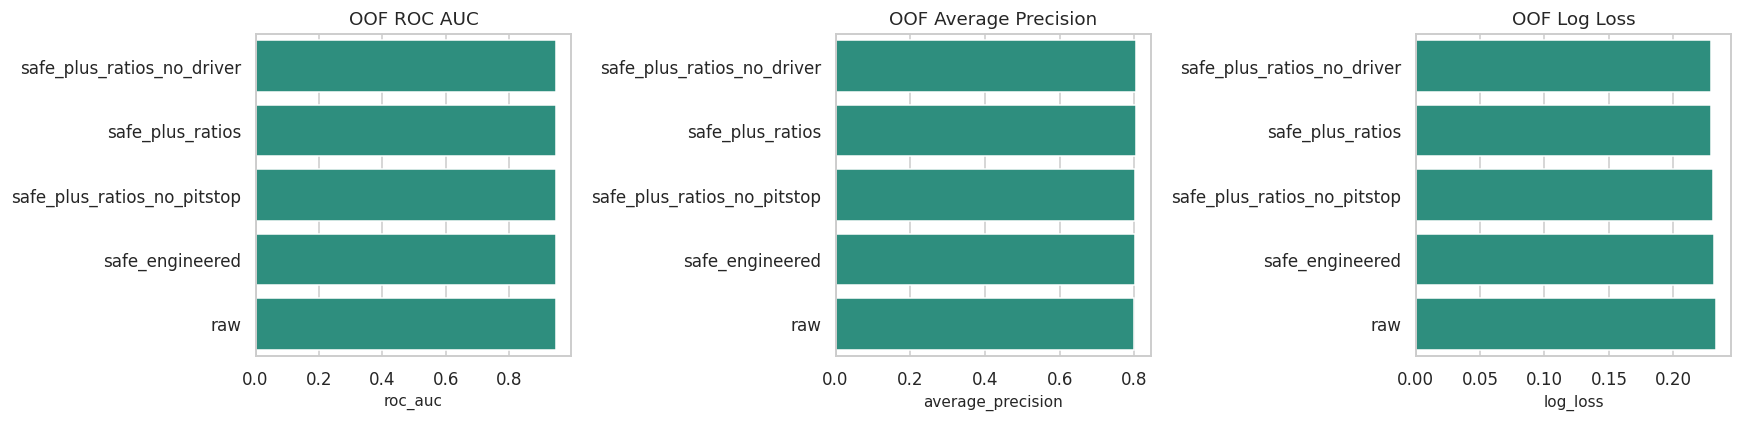

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metric_specs = [
    ("roc_auc", False, "OOF ROC AUC"),
    ("average_precision", False, "OOF Average Precision"),
    ("log_loss", True, "OOF Log Loss"),
]

for ax, (metric, ascending, title) in zip(axes, metric_specs):
    order = summary.sort_values(metric, ascending=ascending)["feature_set"]
    sns.barplot(data=summary, y="feature_set", x=metric, order=order, color=sns.color_palette("viridis", 8)[4], ax=ax)
    ax.set_title(title)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

## 7. Slice Error Analysis

In [8]:
best_feature_set = summary.iloc[0]["feature_set"]
best_data = feature_set_data[best_feature_set].reset_index(drop=True)
best_oof = oof_predictions[best_feature_set]

slice_df = best_data[[TARGET, "Compound", "Stint", "RaceProgress", "TyreLife"]].copy()
slice_df["prediction"] = best_oof
slice_df["RaceProgress_bin"] = pd.qcut(slice_df["RaceProgress"], q=5, duplicates="drop")
slice_df["TyreLife_bin"] = pd.qcut(slice_df["TyreLife"], q=5, duplicates="drop")


def slice_metrics(df: pd.DataFrame, col: str, min_count: int = 100) -> pd.DataFrame:
    rows = []
    for value, part in df.groupby(col, observed=True):
        if len(part) < min_count or part[TARGET].nunique() < 2:
            continue
        metrics = evaluate_predictions(part[TARGET], part["prediction"])
        metrics.update({
            "slice": col,
            "value": str(value),
            "count": len(part),
            "target_rate": part[TARGET].mean(),
            "prediction_mean": part["prediction"].mean(),
        })
        rows.append(metrics)
    return pd.DataFrame(rows)


slice_results = pd.concat([
    slice_metrics(slice_df, "Compound"),
    slice_metrics(slice_df, "Stint"),
    slice_metrics(slice_df, "RaceProgress_bin"),
    slice_metrics(slice_df, "TyreLife_bin"),
], ignore_index=True)

slice_results.sort_values("log_loss", ascending=False)

,roc_auc,average_precision,log_loss,slice,value,count,target_rate,prediction_mean
6,0.910293,0.844382,0.361247,Stint,2,53165,0.389636,0.389842
14,0.918865,0.841884,0.339920,RaceProgress_bin,"(0.359, 0.571]",35877,0.356719,0.356592
0,0.927179,0.838001,0.315222,Compound,HARD,69940,0.326079,0.326008
7,0.921830,0.799523,0.314434,Stint,3,28126,0.294141,0.293452
20,0.947176,0.889436,0.275906,TyreLife_bin,"(22.0, 77.0]",33469,0.362156,0.362153
19,0.940095,0.817791,0.271177,TyreLife_bin,"(15.0, 22.0]",35473,0.271784,0.271813
15,0.943730,0.836032,0.262968,RaceProgress_bin,"(0.571, 1.0]",35811,0.270978,0.271220
3,0.929353,0.760154,0.260041,Compound,SOFT,15784,0.196275,0.195031
18,0.934274,0.743641,0.251620,TyreLife_bin,"(10.0, 15.0]",35785,0.197150,0.196623
13,0.937671,0.776593,0.248386,RaceProgress_bin,"(0.205, 0.359]",36212,0.199713,0.198954


## 8. Train Selected Feature Set and Submit

In [9]:
selected_feature_set = best_feature_set
selected_config = feature_set_configs[selected_feature_set]

train_selected = prepare_feature_set(train, selected_config)
test_selected = prepare_feature_set(test, selected_config)

X_train = train_selected.drop(columns=[TARGET])
y_train = train_selected[TARGET].astype("int8")
X_test = test_selected.copy()

final_preprocessor = make_preprocessor(X_train)
X_train_processed = final_preprocessor.fit_transform(X_train)
X_test_processed = final_preprocessor.transform(X_test)

final_model = LGBMClassifier(**lgbm_params)
final_model.fit(X_train_processed, y_train)

test_pred = final_model.predict_proba(X_test_processed)[:, 1]
test_pred = np.clip(test_pred, 1e-6, 1 - 1e-6)

submission = sample_submission.copy()
submission[TARGET] = test_pred
submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

comparison.to_csv(OUTPUT_DIR / "feature_validation_summary.csv", index=False)
fold_results.to_csv(OUTPUT_DIR / "feature_validation_fold_results.csv", index=False)
slice_results.to_csv(OUTPUT_DIR / "feature_validation_slice_results.csv", index=False)

print("Selected feature set:", selected_feature_set)
print("Saved:", submission_path)
submission.head()

Selected feature set: safe_plus_ratios_no_driver
Saved: /kaggle/working/submission.csv


,id,PitNextLap
0,439140,0.006827
1,439141,0.002203
2,439142,0.003025
3,439143,0.163947
4,439144,0.883381


## 9. Decision Rules

- Keep a feature set only if it improves OOF AUC or log loss and the gain is stable across folds.
- Be skeptical of tyre-ratio features if they improve fast-mode CV but fail on full-data CV or produce poor slice calibration.
- If removing `Driver` barely hurts performance, prefer the simpler model because it may generalize better.
- If removing `PitStop` hurts substantially, decide whether it is valid competition-time information before relying on it.